**This code generates the information about dataset**

In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [12]:
def get_dataset_info(data_dir, top_n=None):
    # Load the train and validation dataset
    train_datapath = os.path.join(data_dir, 'train_aug_labels.csv')
    val_datapath = os.path.join(data_dir, 'val_labels.csv')
    test_datapath = os.path.join(data_dir, 'test_labels.csv')

    train_df = pd.read_csv(train_datapath) 
    val_df = pd.read_csv(val_datapath) 
    test_df = pd.read_csv(test_datapath)
    combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    classes = set(combined_df['species'])
    # classes = os.listdir(data_dir)
    n_classes = len(classes)
    cls_info = {}
    for c in classes:
        images = combined_df[combined_df['species']==c]['images']
        n_imgs = len(images)
        cls_info[c] = n_imgs
    # cls_info = dict(sorted(cls_info.items(), key=lambda x: x[1], reverse=True))
    total_imgs = sum(cls_info.values())
    print(f"Infor for dataset: {data_dir}")
    print(f"Total classes: {n_classes}")
    print(f"Total images: {total_imgs}")
    print("📊 Class distribution:")
    for i, c in enumerate(cls_info):
        print(f"{i+1}. {c}: {cls_info[c]}")

    # Extract data
    classes, counts = list(cls_info.keys()), list(cls_info.values())

    if top_n:
        classes, counts = classes[:top_n], counts[:top_n]

    # --- Plot 1: Bar plot (unsorted) ---
    plt.figure(figsize=(20, 6))
    sns.barplot(x=classes, y=counts, palette="viridis")
    plt.xticks(rotation=90)
    plt.title("Class Distribution (Bar Plot)")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.show()

    # --- Plot 2: Histogram of counts ---
    plt.figure(figsize=(8, 5))
    sns.histplot(counts, bins=30, kde=True, color="blue")
    plt.title("Distribution of Image Counts per Class")
    plt.xlabel("Number of Images")
    plt.ylabel("Frequency of Classes")
    plt.show()
    
    return cls_info

Infor for dataset: /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5
Total classes: 160
Total images: 36651
📊 Class distribution:
1. Bombus_ternarius: 440
2. Bombus_cryptarum: 220
3. Bombus_affinis: 2587
4. Bombus_vandykei: 410
5. Bombus_sitkensis: 435
6. Bombus_haematurus: 50
7. Bombus_lapponicus: 41
8. Bombus_magnus: 25
9. Bombus_mucidus: 12
10. Bombus_breviceps: 6
11. Bombus_flavidus: 385
12. Bombus_jonellus: 425
13. Bombus_lucorum: 414
14. Bombus_macgregori: 13
15. Bombus_medius: 375
16. Bombus_mexicanus: 298
17. Bombus_huntii: 410
18. Bombus_brasiliensis: 177
19. Bombus_gerstaeckeri: 6
20. Bombus_lapidarius: 430
21. Bombus_impatiens: 425
22. Bombus_morrisoni: 440
23. Bombus_lantschouensis: 6
24. Bombus_insularis: 425
25. Bombus_festivus: 6
26. Bombus_coreanus: 8
27. Bombus_hortorum: 450
28. Bombus_consobrinus: 88
29. Bombus_mixtus: 455
30. Bombus_norvegicus: 18
31. Bombus_opulents: 22
32. Bombus_caliginosus: 225
33. Bombus_koreanus: 80
34. Bombus_humilis: 385
35. Bombus_a

/tmp/ipykernel_2635759/3909576741.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette="viridis")


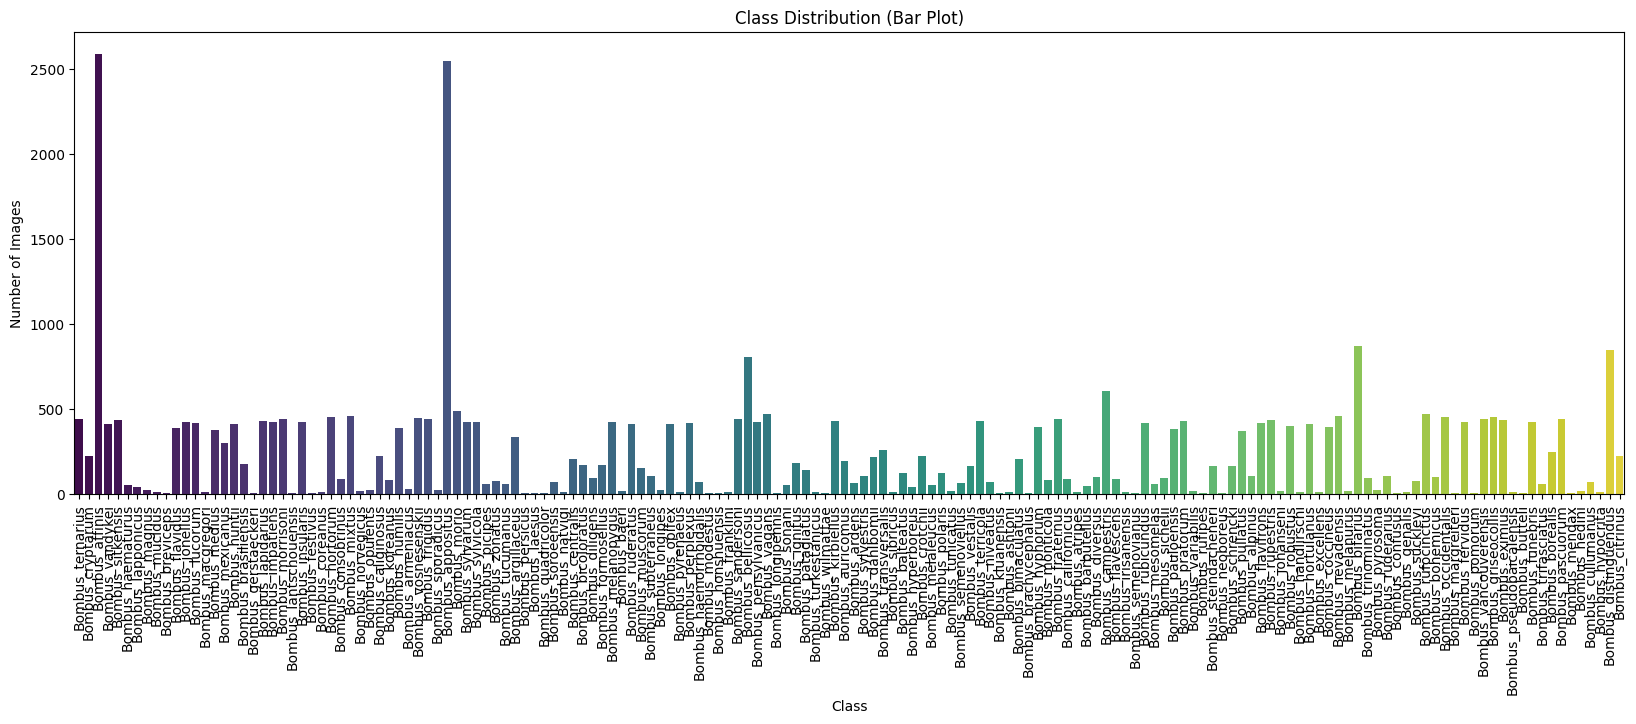

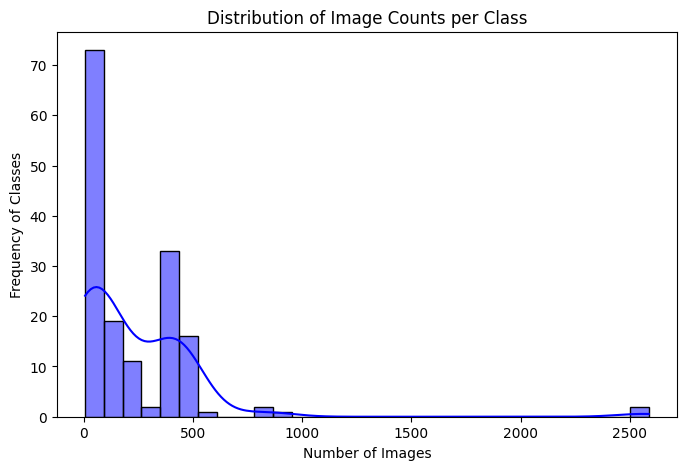

In [13]:
datadir = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5"
data_info = get_dataset_info(datadir)